# Data Preparation — Dataset Performa Siswa

**Nama:** Clarissa Indriana Pramesti

**NPM:** 2306211660

**Mata Kuliah:** Business Intelligence  

**Topik:** Data Cleaning & Preparation menggunakan Python untuk Lab Tableau


## 0. Import Library


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Konfigurasi tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

print('Library berhasil diimport.')

Library berhasil diimport.


## 1. Load Dataset & Eksplorasi Awal

Langkah pertama adalah memuat dataset dan melakukan eksplorasi awal untuk memahami dimensi, tipe data, dan gambaran statistik dari setiap kolom.

### Load dataset

In [46]:
df = pd.read_csv('DatasetPerformaSiswa.csv')

print(f'Jumlah baris   : {df.shape[0]:,}')
print(f'Jumlah kolom   : {df.shape[1]}')
print(f'\n aftar kolom   :')
print(df.columns.tolist())

Jumlah baris   : 6,607
Jumlah kolom   : 20

 aftar kolom   :
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']


In [47]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [48]:
print('Informasi tipe data:')
df.info()

Informasi tipe data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence             

### Statistik deskriptif kolom numerik

In [49]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00
mean,19.98,79.98,7.03,75.07,1.49,2.97,67.24
std,5.99,11.55,1.47,14.40,1.23,1.03,3.89
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,101.00


## 2. Pengecekan & Penanganan *Null Values*

Keberadaan *null values* dapat memengaruhi hasil analisis, sehingga perlu dideteksi dan ditangani terlebih dahulu.


In [50]:
# Hitung jumlah dan persentase null per kolom
null_count = df.isnull().sum()
null_pct   = (null_count / len(df) * 100).round(2)

null_summary = pd.DataFrame({
    'Jumlah Null'     : null_count,
    'Persentase (%)' : null_pct
}).query('`Jumlah Null` > 0')

print('Kolom dengan Null Values:')
print(null_summary)
print(f'\nTotal baris dengan setidaknya 1 null: {df.isnull().any(axis=1).sum():,}')

Kolom dengan Null Values:
                          Jumlah Null  Persentase (%)
Teacher_Quality                    78            1.18
Parental_Education_Level           90            1.36
Distance_from_Home                 67            1.01

Total baris dengan setidaknya 1 null: 229


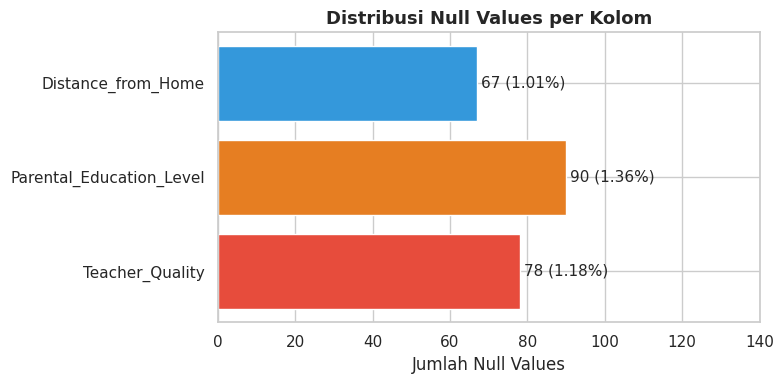

Visualisasi null values tersimpan sebagai null_values.png


In [51]:
# Visualisasi null values
cols_with_null = null_summary.index.tolist()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(cols_with_null, null_summary['Jumlah Null'], color=['#E74C3C','#E67E22','#3498DB'])

for bar, val, pct in zip(bars, null_summary['Jumlah Null'], null_summary['Persentase (%)']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val} ({pct}%)', va='center', fontsize=11)

ax.set_xlabel('Jumlah Null Values')
ax.set_title('Distribusi Null Values per Kolom', fontsize=13, fontweight='bold')
ax.set_xlim(0, 140)
plt.tight_layout()
plt.savefig('null_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi null values tersimpan sebagai null_values.png')

### Temuan Null Values

Ditemukan **3 kolom** yang memiliki *null values*:

Persentase *missing values* sangat kecil (masing-masing < 1,5%). Strategi yang dipilih adalah **imputasi dengan modus** (nilai yang paling sering muncul) untuk kolom kategorik, karena:
- Menghapus baris (*drop*) akan membuang data yang mayoritas lengkap
- Modus adalah representasi distribusi yang valid untuk data kategorik


In [52]:
# Imputasi null values dengan modus pada masing-masing kolom
for col in ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f' [{col}] — null diisi dengan modus: "{mode_val}"')

print(f'\nSisa null values setelah imputasi: {df.isnull().sum().sum()}')

 [Teacher_Quality] — null diisi dengan modus: "Medium"
 [Parental_Education_Level] — null diisi dengan modus: "High School"
 [Distance_from_Home] — null diisi dengan modus: "Near"

Sisa null values setelah imputasi: 0


## 3. Pengecekan & Penanganan *Duplicate Data*

*Duplicate data* adalah baris yang memiliki nilai yang identik pada seluruh kolomnya. Duplikat dapat menyebabkan bias dalam analisis dan perlu dihapus.


In [53]:
jumlah_duplikat = df.duplicated().sum()

print(f'Jumlah baris duplikat ditemukan : {jumlah_duplikat}')

if jumlah_duplikat > 0:
    print('\nMenghapus baris duplikat')
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'Baris duplikat berhasil dihapus. Sisa data: {len(df):,} baris.')
else:
    print('Tidak ditemukan baris duplikat. Tidak ada yang perlu dihapus.')

Jumlah baris duplikat ditemukan : 0
Tidak ditemukan baris duplikat. Tidak ada yang perlu dihapus.


### Temuan Duplicate Data

Tidak ditemukan **baris duplikat** pada dataset ini. Dataset memiliki entri yang unik di setiap barisnya, sehingga tidak diperlukan langkah penghapusan.


## 4. Pengecekan & Penanganan *Outlier Values*

*Outlier* adalah nilai yang berada jauh di luar rentang distribusi normal data. Metode yang digunakan adalah **IQR (Interquartile Range)**:

$$\text{Lower Bound} = Q1 - 1.5 \times IQR$$
$$\text{Upper Bound} = Q3 + 1.5 \times IQR$$

Nilai di luar kedua batas tersebut dikategorikan sebagai *outlier*.


In [54]:
# Identifikasi outlier pada semua kolom numerik
num_cols = df.select_dtypes(include='number').columns.tolist()

outlier_summary = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_summary.append({
        'Kolom'          : col,
        'Q1'             : Q1,
        'Q3'             : Q3,
        'IQR'            : IQR,
        'Lower Bound'    : lower,
        'Upper Bound'    : upper,
        'Min Aktual'     : df[col].min(),
        'Max Aktual'     : df[col].max(),
        'Jumlah Outlier' : n_out,
    })

outlier_df = pd.DataFrame(outlier_summary)
print('Ringkasan Outlier Detection:')
outlier_df

Ringkasan Outlier Detection:


,Kolom,Q1,Q3,IQR,Lower Bound,Upper Bound,Min Aktual,Max Aktual,Jumlah Outlier
0,Hours_Studied,16.00,24.00,8.00,4.00,36.00,1,44,43
1,Attendance,70.00,90.00,20.00,40.00,120.00,60,100,0
2,Sleep_Hours,6.00,8.00,2.00,3.00,11.00,4,10,0
3,Previous_Scores,63.00,88.00,25.00,25.50,125.50,50,100,0
4,Tutoring_Sessions,1.00,2.00,1.00,-0.50,3.50,0,8,430
5,Physical_Activity,2.00,4.00,2.00,-1.00,7.00,0,6,0
6,Exam_Score,65.00,69.00,4.00,59.00,75.00,55,101,104


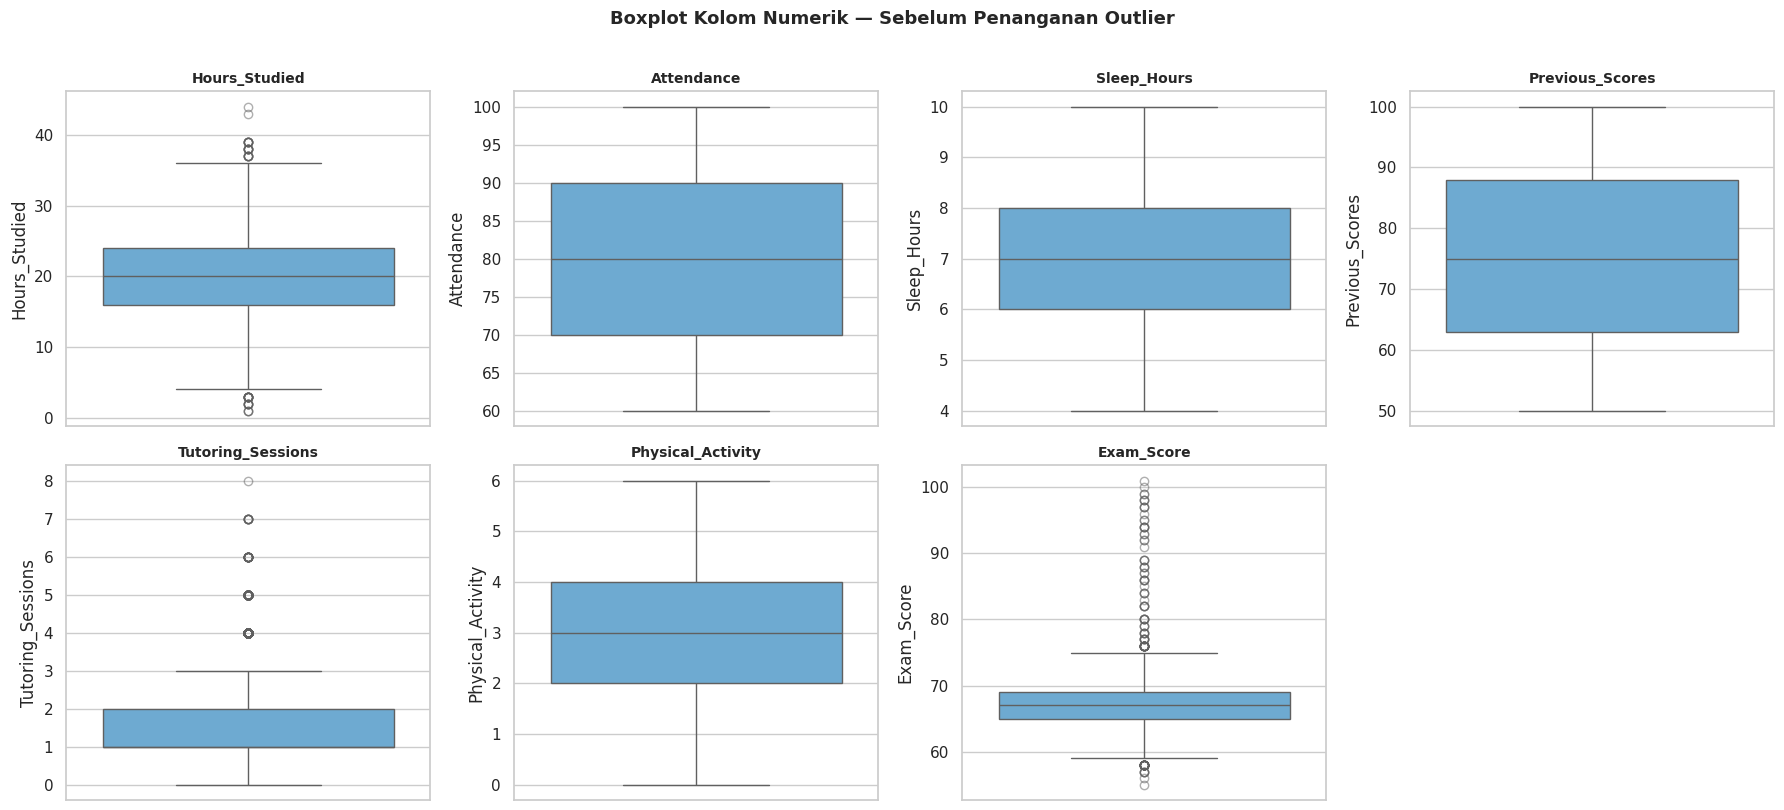

Boxplot sebelum penanganan tersimpan sebagai boxplot_before.png


In [55]:
# Visualisasi boxplot seluruh kolom numerik
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#5DADE2', flierprops=dict(marker='o', color='red', alpha=0.5))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

# Sembunyikan subplot kosong jika ada
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Kolom Numerik — Sebelum Penanganan Outlier', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplot_before.png', dpi=150, bbox_inches='tight')
plt.show()
print('Boxplot sebelum penanganan tersimpan sebagai boxplot_before.png')

### Temuan Outlier

**Strategi penanganan:**
- `Hours_Studied` & `Tutoring_Sessions` -> **Tidak dihapus**, karena nilai masih masuk akal secara konteks (domain knowledge)
- `Exam_Score > 100` -> **Dihapus**, karena nilai ujian tidak mungkin melebihi 100 (data error/input error)


In [56]:
# Cek nilai Exam_Score yang melebihi 100
invalid_score = df[df['Exam_Score'] > 100]
print(f'Baris dengan Exam_Score > 100: {len(invalid_score)}')
print(f'   Nilai unik yang invalid: {sorted(invalid_score["Exam_Score"].unique())}')
print()

# Hapus baris dengan Exam_Score invalid
df = df[df['Exam_Score'] <= 100].reset_index(drop=True)
print(f'Baris dengan Exam_Score > 100 berhasil dihapus.')
print(f'   Sisa data: {len(df):,} baris')

Baris dengan Exam_Score > 100: 1
   Nilai unik yang invalid: [np.int64(101)]

Baris dengan Exam_Score > 100 berhasil dihapus.
   Sisa data: 6,606 baris


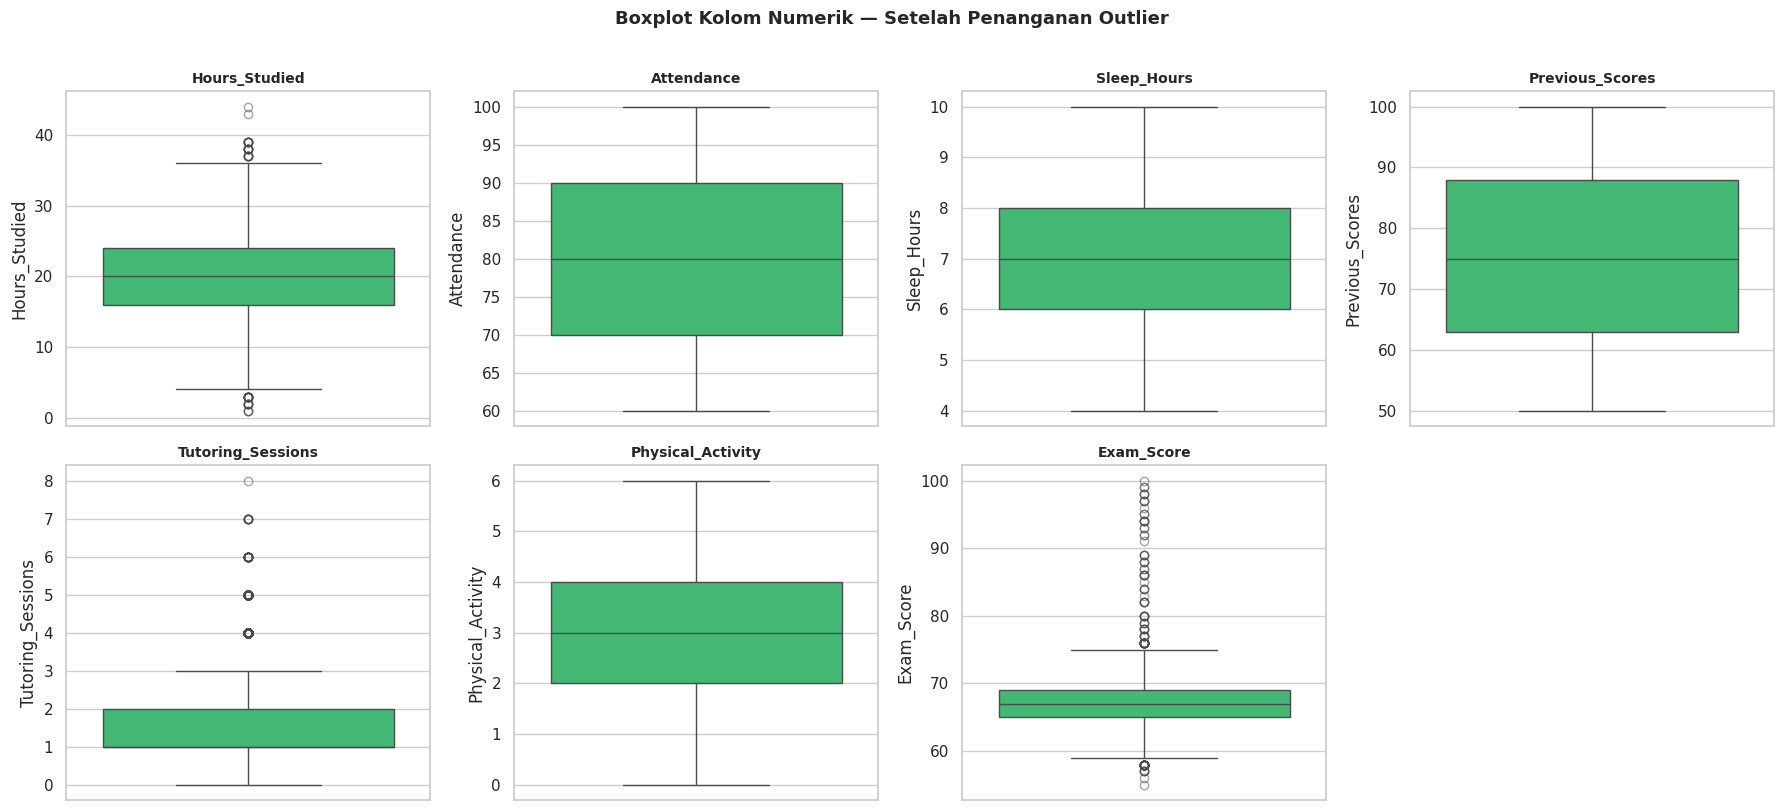

Boxplot setelah penanganan tersimpan sebagai boxplot_after.png


In [37]:
# Visualisasi boxplot setelah penanganan
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#2ECC71', flierprops=dict(marker='o', color='red', alpha=0.5))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Kolom Numerik — Setelah Penanganan Outlier', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplot_after.png', dpi=150, bbox_inches='tight')
plt.show()
print('Boxplot setelah penanganan tersimpan sebagai boxplot_after.png')

## 5. Pengecekan Tipe Data & Konsistensi Nilai Kategorik

Tahap ini memastikan bahwa:
1. Tipe data setiap kolom sudah sesuai
2. Nilai pada kolom kategorik bersifat konsisten (tidak ada typo, kapitalisasi berbeda, dll.)


In [38]:
# Cek tipe data semua kolom
print('Tipe data semua kolom:')
print(df.dtypes)

Tipe data semua kolom:
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object


In [39]:
# Tampilkan nilai unik pada setiap kolom kategorik
cat_cols = df.select_dtypes(include='object').columns.tolist()

print('Nilai unik pada kolom kategorik:')
for col in cat_cols:
    unique_vals = sorted(df[col].dropna().unique())
    print(f'  [{col}] ({len(unique_vals)} nilai): {unique_vals}')

Nilai unik pada kolom kategorik:
  [Parental_Involvement] (3 nilai): ['High', 'Low', 'Medium']
  [Access_to_Resources] (3 nilai): ['High', 'Low', 'Medium']
  [Extracurricular_Activities] (2 nilai): ['No', 'Yes']
  [Motivation_Level] (3 nilai): ['High', 'Low', 'Medium']
  [Internet_Access] (2 nilai): ['No', 'Yes']
  [Family_Income] (3 nilai): ['High', 'Low', 'Medium']
  [Teacher_Quality] (3 nilai): ['High', 'Low', 'Medium']
  [School_Type] (2 nilai): ['Private', 'Public']
  [Peer_Influence] (3 nilai): ['Negative', 'Neutral', 'Positive']
  [Learning_Disabilities] (2 nilai): ['No', 'Yes']
  [Parental_Education_Level] (3 nilai): ['College', 'High School', 'Postgraduate']
  [Distance_from_Home] (3 nilai): ['Far', 'Moderate', 'Near']
  [Gender] (2 nilai): ['Female', 'Male']


In [40]:
# Standardisasi: strip whitespace dan seragamkan kapitalisasi (Title Case)
for col in cat_cols:
    df[col] = df[col].str.strip().str.title()

print('Standardisasi nilai kategorik (strip & Title Case) selesai.')

# Verifikasi ulang nilai unik setelah standardisasi
print('\n Nilai unik setelah standardisasi:')
for col in cat_cols:
    print(f'  [{col}]: {sorted(df[col].dropna().unique())}')

Standardisasi nilai kategorik (strip & Title Case) selesai.

 Nilai unik setelah standardisasi:
  [Parental_Involvement]: ['High', 'Low', 'Medium']
  [Access_to_Resources]: ['High', 'Low', 'Medium']
  [Extracurricular_Activities]: ['No', 'Yes']
  [Motivation_Level]: ['High', 'Low', 'Medium']
  [Internet_Access]: ['No', 'Yes']
  [Family_Income]: ['High', 'Low', 'Medium']
  [Teacher_Quality]: ['High', 'Low', 'Medium']
  [School_Type]: ['Private', 'Public']
  [Peer_Influence]: ['Negative', 'Neutral', 'Positive']
  [Learning_Disabilities]: ['No', 'Yes']
  [Parental_Education_Level]: ['College', 'High School', 'Postgraduate']
  [Distance_from_Home]: ['Far', 'Moderate', 'Near']
  [Gender]: ['Female', 'Male']


In [41]:
# Validasi range nilai kolom numerik
validasi = {
    'Attendance'      : (0, 100),
    'Exam_Score'      : (0, 100),
    'Previous_Scores' : (0, 100),
    'Sleep_Hours'     : (0, 24),
    'Hours_Studied'   : (0, 168),
}

print('Validasi range nilai numerik:')
all_valid = True
for col, (lo, hi) in validasi.items():
    out_range = df[(df[col] < lo) | (df[col] > hi)]
    status = 'OK' if len(out_range) == 0 else f' {len(out_range)} nilai di luar range [{lo}, {hi}]'
    print(f'  [{col}] range [{lo}, {hi}] -> {status}')
    if len(out_range) > 0:
        all_valid = False

if all_valid:
    print('\n Semua nilai numerik berada dalam range yang valid.')

Validasi range nilai numerik:
  [Attendance] range [0, 100] -> OK
  [Exam_Score] range [0, 100] -> OK
  [Previous_Scores] range [0, 100] -> OK
  [Sleep_Hours] range [0, 24] -> OK
  [Hours_Studied] range [0, 168] -> OK

 Semua nilai numerik berada dalam range yang valid.


### Temuan Validasi Tipe Data & Kategorik

| Aspek | Temuan |
|---|---|
| Tipe data | Semua kolom sudah sesuai tipe (numerik untuk skor/jam, string untuk kategorik) |
| Nilai kategorik | Tidak ditemukan typo atau inkonsistensi. Standardisasi *strip + Title Case* diterapkan sebagai langkah preventif |
| Range numerik | Semua nilai numerik berada dalam range yang valid setelah penghapusan `Exam_Score > 100` |


## 6. Ringkasan Proses Data Cleaning

Berikut adalah ringkasan seluruh langkah *data preparation* yang telah dilakukan beserta hasilnya.


In [42]:
print('=' * 60)
print('        RINGKASAN DATA CLEANING')
print('=' * 60)
print(f'  Jumlah data awal          : 6.607 baris')
print(f'  Baris duplikat dihapus    : 0')
print(f'  Null values ditangani     : 235 nilai (imputasi modus)')
print(f'  Outlier data error dihapus: {6607 - len(df)} baris (Exam_Score > 100)')
print(f'  Outlier retained          : Hours_Studied, Tutoring_Sessions')
print(f'  Standardisasi kategorik   : strip + Title Case')
print(f'  ----------------------------------------')
print(f'  Jumlah data akhir (bersih): {len(df):,} baris')
print(f'  Jumlah kolom              : {df.shape[1]}')
print('=' * 60)

        RINGKASAN DATA CLEANING
  Jumlah data awal          : 6.607 baris
  Baris duplikat dihapus    : 0
  Null values ditangani     : 235 nilai (imputasi modus)
  Outlier data error dihapus: 1 baris (Exam_Score > 100)
  Outlier retained          : Hours_Studied, Tutoring_Sessions
  Standardisasi kategorik   : strip + Title Case
  ----------------------------------------
  Jumlah data akhir (bersih): 6,606 baris
  Jumlah kolom              : 20


In [43]:
# Final check: tidak ada null tersisa
sisa_null = df.isnull().sum().sum()
print(f'Total null values tersisa : {sisa_null}')
print(f'Total duplikat tersisa    : {df.duplicated().sum()}')
print()

# Tampilkan statistik akhir
print('Statistik deskriptif dataset bersih:')
df.describe()

Total null values tersisa : 0
Total duplikat tersisa    : 0

Statistik deskriptif dataset bersih:


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6606.00,6606.00,6606.00,6606.00,6606.00,6606.00,6606.00
mean,19.97,79.97,7.03,75.07,1.49,2.97,67.23
std,5.99,11.55,1.47,14.40,1.23,1.03,3.87
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,100.00


## 7. Export Dataset Bersih


In [44]:
output_path = 'DatasetPerformaSiswa_Clean.csv'
df.to_csv(output_path, index=False)

# Verifikasi file yang tersimpan
df_verify = pd.read_csv(output_path)
print(f'Dataset bersih berhasil disimpan ke: {output_path}')
print(f'   Shape   : {df_verify.shape[0]:,} baris × {df_verify.shape[1]} kolom')
print(f'   Null    : {df_verify.isnull().sum().sum()}')
print(f'   Duplikat: {df_verify.duplicated().sum()}')
print()

Dataset bersih berhasil disimpan ke: DatasetPerformaSiswa_Clean.csv
   Shape   : 6,606 baris × 20 kolom
   Null    : 0
   Duplikat: 0



## Kesimpulan

Proses *data preparation* pada `DatasetPerformaSiswa.csv` telah selesai dilakukan. Berikut adalah rangkuman seluruh temuan dan tindakan yang diambil:

| # | Tahap | Temuan | Tindakan |
|---|---|---|---|
| 1 | **Eksplorasi Awal** | 6.607 baris, 20 kolom, 7 kolom numerik | Memahami struktur dan distribusi data |
| 2 | **Null Values** | 3 kolom (`Teacher_Quality`, `Parental_Education_Level`, `Distance_from_Home`) dengan total 235 null | Imputasi menggunakan **modus** masing-masing kolom |
| 3 | **Duplicate Data** | Tidak ditemukan duplikat | Tidak ada tindakan (data sudah unik) |
| 4 | **Outlier** | `Exam_Score > 100` (data error), outlier pada `Hours_Studied` & `Tutoring_Sessions` (masih valid secara konteks) | Hapus baris dengan `Exam_Score > 100`; retain outlier lainnya |
| 5 | **Tipe Data & Kategorik** | Tipe data sudah sesuai; nilai kategorik konsisten | Standardisasi *strip + Title Case* sebagai langkah preventif |